# Week 0 Overview

## Day 1

### Pre Set up
Initial setup, Python 3.10.20 and uv for virtual env. Jupyter lab, ffmpeg installed. WSL setup done. 

### Numpy
Numpy arrays and how they are different from python lists. 
Numpy arrays are stored in C, reducing size as compared to python lists which stores pointers to obj. The math functions are much faster on np compared to lists. 

### Data Types
Different types of data types.  

int32 - 4 B storage  
int64 - 8 B  
float32 - 4 B  
float64 - 8 B  
boolean - 1 B  

Its useful when we want to save up on storage for models/programs.

### Shape
Refers to the dimensions of the array.
Can be 1d, 2d, 3d+
Dimensions are important when we want to multiple or add. Difference in dimensions can cause errors.

### Jupyter Notebook
ipynb - interactive python notebook

used when we are experimenting with code or in development process. when experimenting, we dont want to run the whole code, we only want to run certain parts, to save time. The NB consists of cells like code and markdown. Its mainly python based. We can also run and see output directly in the notebook like graphs. We can also decide the order in which the cells are run.

There is a kernel in the notebook. This kernel helps to actually helps run the code in the notebook. The notebook is just the interface, it can only run the code when it connects to the kernel. The kernel also stores the data and variables in it. 

If we face issues during execution, we can restart the kernel, most issues get solved. 

### Testing Kernel and order of running commands

In [52]:
print("Hello")
x=5

Hello


In [53]:
x=10

In [54]:
print(x)

10


### Numpy exercises
Prediction of shape in markdown followed by code cell 

In [55]:
import numpy as np

1. 3,4

In [56]:
a = np.zeros((3, 4))
a.shape

(3, 4)

2. 3,5

In [57]:
a = np.arange(30).reshape(6, 5)
b = a[1:4]
b.shape

(3, 5)

3. 6,

In [58]:
a = np.arange(30).reshape(6, 5)
b = a[:, 2]
b.shape

(6,)

4. 4,3,2

In [59]:
a = np.arange(24)
b = a.reshape(4, 3, 2)
b.shape

(4, 3, 2)

5. 4,6

In [60]:
a = np.arange(24)
b = a.reshape(-1, 6)
b.shape

(4, 6)

6. 3,

In [61]:
A = np.ones((3, 4))
v = np.ones(4)
out = A @ v
out.shape

(3,)

7. 3,5

In [62]:
A = np.ones((3, 4))
B = np.ones((4, 5))
out = A @ B
out.shape

(3, 5)

8. 3,4


In [63]:
a = np.ones((3, 4))
b = a * 5
b.shape

(3, 4)

9. 4,3

In [64]:
a = np.ones((4, 3))
b = np.array([10, 20, 30])
c = a + b
c.shape

(4, 3)

10. 4,3

In [65]:
a = np.ones((4, 3))
b = np.array([[10], [20], [30], [40]])
c = a + b
c.shape

(4, 3)

### Axis in Numpy
Axis is used when we want to collapse and sum-up a row, coloum or both. 
axis=0, the rows collapse 
axis=1, columns collapse
(), whole array dissolves into one

In [66]:
a = np.ones((4, 3))
print(a.shape)

b = a.sum(axis=0) #will collapse rows
print(b.shape)

c = a.sum(axis=1) #collapses columns
print(c.shape)

d = a.sum() #everything collapsed into 1
print(d.shape)

(4, 3)
(3,)
(4,)
()


## Day 2

### Line Plot - Plot

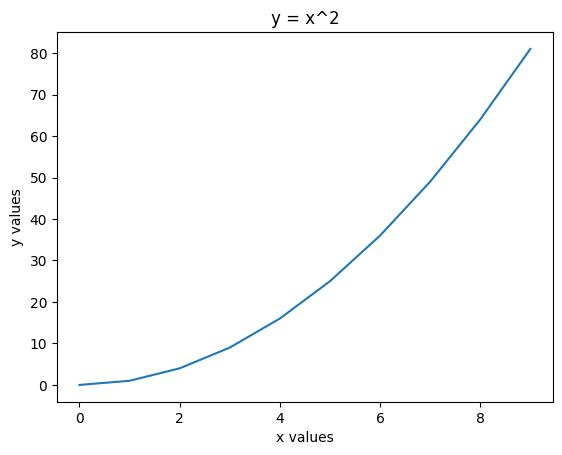

In [67]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 10)
y = x ** 2

fig, ax = plt.subplots()

ax.plot(x, y)

ax.set_title("y = x^2")
ax.set_xlabel("x values")
ax.set_ylabel("y values")

plt.show()

### Line Graph - Plot

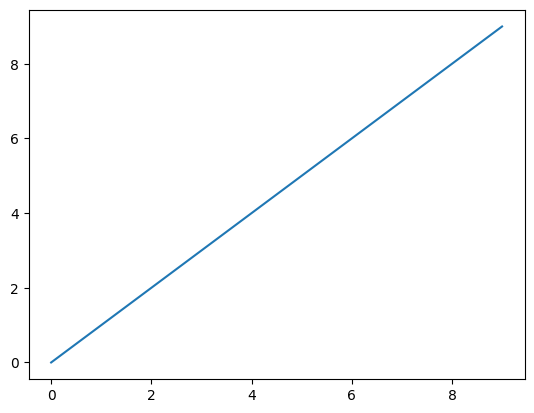

In [68]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(10)
fig, ax = plt.subplots()
ax.plot(x)
plt.show()

### Sine Wave Graph

Text(0.5, 1.0, 'Sine Wave')

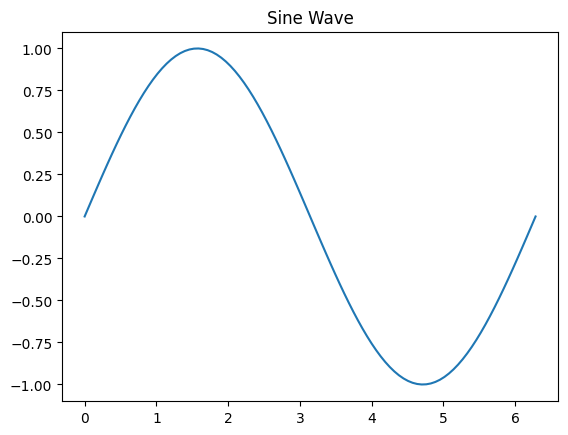

In [69]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,2*np.pi,100)
y = np.sin(x)

plt.plot(x,y)
plt.title("Sine Wave")

### Gaussion Graph

Text(0.5, 1.0, 'Hist')

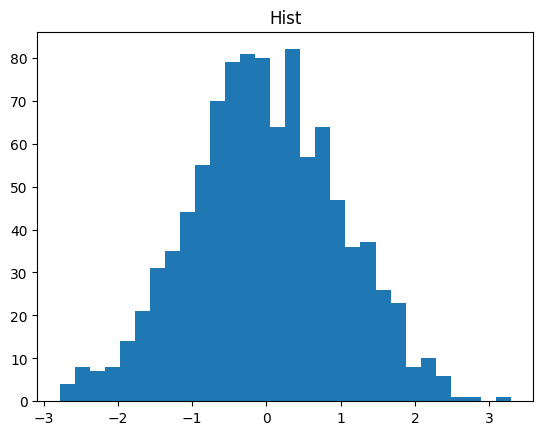

In [70]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.randn(1000)

fig, ax = plt.subplots()

ax.hist(data,bins=30)

ax.set_title("Hist")

### Correlation

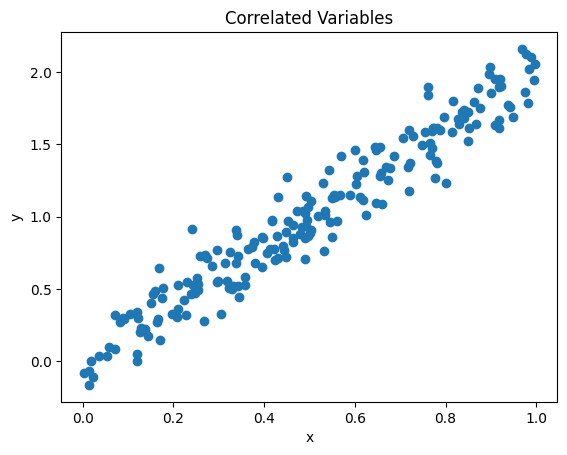

In [71]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.rand(200)

noise = np.random.randn(200) * 0.15

y = 2 * x + noise

fig, ax = plt.subplots()

ax.scatter(x, y)

ax.set_title("Correlated Variables")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

## Librosa

When a mic is recording sound, it is actually recording the airpressure around the mic in a very small fraction of time. Each time, it takes the airpressure and stores it. These airpressures together make the waveform of the sound.

The number of samples taken per second is called the sample rate. The most common ones are 16k and 44.1k

#### How librosa loads sound

In [72]:
import librosa
y, sr = librosa.load(librosa.ex('trumpet'))
print("Waveform shape:", y.shape)
print("Sample rate:", sr)

Waveform shape: (117601,)
Sample rate: 22050


Here
y - waveform
sr is sample rate

We cannot make preductions just from the waveform because it just tells us the loudness of the sound wave.

So we use spectrogram to convert it into time vs frequency. 

In [73]:
spectrogram = librosa.stft(y)
print("Spectrogram shape:", spectrogram.shape)

Spectrogram shape: (1025, 230)


#### MFCC - Mel Frequency Cepstral Coefficients

When we divide the audio on the basis of frequency, like 16kHz, it is not meaningful. 
Theres too much data and no way to make sense of it.

So, MFCC divides the audio into more meaningful chunks of data. For example, it may divide a word on the basis of the syllables it produces. 


In [74]:
mfccs = librosa.feature.mfcc(y=y, sr=sr)
print("MFCC shape:", mfccs.shape)

MFCC shape: (20, 230)


## Day 3 
### Whats a Model in ML
A model in ML is basically a function in short. We give in some input, it processes it and then gives out some output. There can be parameters to the model. Depending on the model, it can give different priority/weight to each parameter. 
For example: A model which predicts if an image is a cat or not.
### Whats a Tensor
Tensor is basically an Numpy Array with some extra steps. A numpy array is stored in the CPU, when we convert the numpy array to a Tensor, it gets stored in the GPU. It's important to store it in the GPU because it can process some tasks much much faster than in the CPU. Repetitive tasks such as matrix multiplication perform much better in GPU. The tensor also tracks gradients, in short, it can remember what operation was performed in memory and store it.

### Whats a Tokenizer
A tokenizer is used to convert human readable text into machine readable. It breaks down the words given to it into numbers which the computer can understand. When given a few words, a tokenizer can break it down into multiple ways. It can take the whole word as one token, or it can break it into multiple tokens. Each word is given a specific token ID. Tokenization is reversible, meaning We can build the same sentence back to the original from the tokens we have.

English  uses the least amount of tokens. Other languages require more tokens for the same task. 

Doubt: 
How is the tokenization method decided? How is it decided that we will use this specific method to encode/decode?
Can we make a tokenizer for personal use or is it hard to make and is there only on large scale?
### Training vs Inference

Training means giving the computer data and telling it to learn from the data. Training refers to the learning process of the model, where it learns to identify patterns. When we give a model 100000 photos of a cat and tell it to learn what is a cat and what is not.

Inference means using what you learned. The model giving output and making decisions based on the data it has trained on is inference. 
### CPU vs GPU
The CPU is the main processor of the system. It has multiple well built cores that can perform complex tasks. CPU is used for daily day to day tasks. 

GPU is used when we wish to perform multiple repetitive tasks such as matrix mul. GPU consists of thousands of small cores that can perform repetitive actions such as matrixx mul and rendering graphics for vdeo games. There is parallelism in GPU.

## Day 4

### Neural Networks
It is a network thats built to learn patterns from data. It consists of smaller parts called neurons. All the neurons are interconnected. The whole network consists of multiple layers. First layer is input layer, then there are Hidden layers, and finally there is Output layer. The network learns to adjust the weights in such a way that the cost is minimum. The lesser the cost is, the more efficient it is.

#### Training
Training is the process of making the model understand its task and make it more efficient with each pass. When we run it once, it has some error, the cost, when we run it the next time, we change the weights in such a way that the cost is reduced. This reduction/improvement in cost with each iteration is what is training. When do do this thousands, millions of times, thats when the model actually improves. We need to train the data multiple times for it to give some actual fruitful answer.

#### Why we need Data
The model needs examples to learn from. Unless we give it those examples/data, the model does not know what is right and what is wrong. For eg: We give it images of numbers 0-9 and label their answers alongwith. 
The model cant train if it has nothing to compare against. If a model makes a mistake, and its wrong, it has no way of knowing that.

### Gradient Descent
It is the optimization method we use to make the neural network better. We aim to reach the least cost in the gradient. We can reach the least cost by finding the slope at points and moving upwards or downwards from it. We move by taking small steps towards the direction of negative slope. We do this till we reach the local minima. To ensure we can also find the global minima, we use a process called SGD. Soichostic Gradient Descent.

### Backpropagation
This refers to backtracking process of a neural network. When we find an error in the cost, we go back through the multiple layers and distrubute the cause of the error in cost likewise. We do this by figuring our how much each weight contributed to the error. Then each of these weights are updated in a way such that the error is reduced in the next iteration. WIth each step, the error slightly reduces a bit. 

### Attention and Transformers
Most models before transformers focused on one word at a time, they did not have a memory to store the previous word. This did not let them develop the whole context of the sentence. It could only focus on one word at a time.

Attention refers to giving more priority to things that matter more. In a sentance, the attention is important because newer words can connect to words depending on the priority of the word. The more importance a word has, the higher its attention will be. 

Transformers were designed so that we can remember the context of the previous words better while moving onto the newer words. It goes in a sequential order. It could do this better because it ran many tokens at the same time parallely, this improved its parallelism. 


# Day 5

## Pytorch Tensor
Pytorch tensor is similar to a numpy array with more capabilities. 
With a tensor, we can move it to a GPU so that we can take advantage of the multiple processors with faster processes. 

Pytorch also has autograd. Autograd is automatic gradient. Basically pytorch automatically calculates the gradient, we dont need to calculate it seperately. We use this when we want to move towards the local minima in our gradient. 

In [75]:
import torch

arr = torch.tensor([1, 2, 3])
print(arr)
print(arr.dtype) 
print(arr.shape)
print(arr.device)

arr = arr.to('cuda') # This moves the tensor to GPU
print(arr)
print(arr.device) # this will show it as cuda:0, the 0 here shows that its the first gpu, in case there are many

arr = arr.to('cpu')
print(arr)
print(arr.device)

tensor([1, 2, 3])
torch.int64
torch.Size([3])
cpu
tensor([1, 2, 3], device='cuda:0')
cuda:0
tensor([1, 2, 3])
cpu


### Claude generated prog to test time diff bw CPU and GPU

In [76]:
import torch
import time

size = 1000

# Create two random 1000x1000 matrices on CPU
a_cpu = torch.randn(size, size)
b_cpu = torch.randn(size, size)

print(f"Matrices created. Shape: {a_cpu.shape}, dtype: {a_cpu.dtype}, device: {a_cpu.device}")

# --- CPU timing ---
start = time.time()
result_cpu = a_cpu @ b_cpu        # @ is the matmul operator
cpu_time = time.time() - start
print(f"\nCPU time: {cpu_time:.4f} seconds")

# --- GPU timing ---
# Move tensors to GPU
a_gpu = a_cpu.to('cuda')
b_gpu = b_cpu.to('cuda')

print(f"\nMoved to GPU. Device: {a_gpu.device}")

# Warm-up run (first GPU op includes setup time — we throw this away)
_ = a_gpu @ b_gpu
torch.cuda.synchronize()

# Real GPU timing
start = time.time()
result_gpu = a_gpu @ b_gpu
torch.cuda.synchronize()
gpu_time = time.time() - start
print(f"GPU time: {gpu_time:.4f} seconds")

# --- The verdict ---
print(f"\n🏁 GPU was {cpu_time / gpu_time:.1f}x faster than CPU")

Matrices created. Shape: torch.Size([1000, 1000]), dtype: torch.float32, device: cpu

CPU time: 0.0100 seconds

Moved to GPU. Device: cuda:0
GPU time: 0.0071 seconds

🏁 GPU was 1.4x faster than CPU


#### Summary of Above Prog

The above program compares the time diff to multiple the matrices bwt CPU and GPU. Firstly the tensor is by default stored in the CPU, only when we manually move it to the GPU using cuda does it move to the GPU. 
We are ignoring the first GPU matmul because the initial setup takes time. factors such as loading cuda libraries, allocating memory may take time. So we ignore the first one and calculate for the second. 
The synchronize part makes python stay in the GPU, usually python will send the data to GPU and move on to next task. Synchronize ensures that it stays there to measure the time.

## Running Distilbert from HF

In [77]:
from transformers import pipeline

pipe = pipeline('sentiment-analysis')

print(pipe('I love this.'))

print(pipe('I am unsure about this. This is pretty bad. But it is good also. But mostly bad.'))


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998741149902344}]
[{'label': 'POSITIVE', 'score': 0.5729963183403015}]


### Above Prog
The above program is from a HF library Transformers. 
The first line is importing the specific pipeline function from transformers package.

Line 2
Here the prog will find default library for sentiment analysis. Thats distilbert. It was made using movie reviews. Movie reviews are usually liike I didnt like or I liked it. They have polarizing rules. So this model can identify if something leans towards positive side or negative. SO it is good for identifying the positive vs negativee.

Line 3
The given line is first tokenized and converted to tokens. The tokens are then sent to distilbert for analysis. It returns the sureity of how certain it is with its prediction. The sentence is pretty basic, so it gives a high certaintity ans.

Line 4
In this line, I have used a lot of unsure wording. I have mixed the sentences with positive/negative and combined them into one line to test the limits of the model. THe model failed here as it could only predict with 57% certainty.